# Random Forest Results Analysis

This notebook has all the plots for the MPI + OpenMP Random Forest project.

It focuses on:
- comparing the latest Serial, OpenMP, MPI, and Hybrid runs
- visualizing validation metrics such as accuracy, precision, recall, F1, and overhead
- comparing runtime across implementations
- summarizing multi-seed hybrid experiments

In [20]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def find_results_dir(start: Path) -> Path:
    start = start.resolve()
    candidates = [start] + list(start.parents)
    for candidate in candidates:
        if (candidate / "Results" / "runs").exists():
            return candidate / "Results"
        if (candidate / "runs").exists() and candidate.name == "Results":
            return candidate
    raise FileNotFoundError(
        "Could not find a Results directory with a runs/ folder. "
        "Open the notebook inside the project repo or set the working directory to the repo root."
    )

RESULTS_DIR = find_results_dir(Path.cwd())
RUNS_DIR = RESULTS_DIR / "runs"
print("Results directory:", RESULTS_DIR)
print("Available run folders:", len(list(RUNS_DIR.glob("run_*"))))
RUNS_DIR


Results directory: /Users/benstahatch/Documents/Hybrid-Revision/csci4330-fall2025-group/Results
Available run folders: 8


PosixPath('/Users/benstahatch/Documents/Hybrid-Revision/csci4330-fall2025-group/Results/runs')

In [21]:
def load_runs(runs_dir: Path) -> pd.DataFrame:
    rows = []
    for metrics_path in sorted(runs_dir.glob("run_*/metrics.json")):
        with metrics_path.open("r", encoding="utf-8") as infile:
            data = json.load(infile)
        data["run_name"] = metrics_path.parent.name
        data["metrics_path"] = str(metrics_path)
        rows.append(data)
    if not rows:
        raise ValueError("No run metrics found under Results/runs/run_*/metrics.json")
    return pd.DataFrame(rows)

runs_df = load_runs(RUNS_DIR)
runs_df.head()


,model_name,train_size,validation_size,mpi_ranks,omp_threads,train_fraction,split_seed,n_trees,max_depth,min_samples_split,...,precision,recall,f1,overhead,tp,tn,fp,fn,run_name,metrics_path
0,Random Forest (Backup MPI),614,154,2,1.0,0.8,42,100,10,2,...,78.9474,27.7778,41.0959,27.9221,15,96,4,39,run_20260430_164927_393_backup_mpi_rf_r2_th1_s...,/Users/benstahatch/Documents/Hybrid-Revision/c...
1,Random Forest (Hybrid),614,154,2,NaN,0.8,7,300,12,10,...,82.3529,51.8519,63.6364,20.7792,28,94,6,26,run_20260430_204408_613_r2_seed7_t300_d12_ms10...,/Users/benstahatch/Documents/Hybrid-Revision/c...
2,Random Forest (Hybrid),614,154,2,NaN,0.8,21,300,12,10,...,68.2927,51.8519,58.9474,25.3247,28,87,13,26,run_20260430_204408_825_r2_seed21_t300_d12_ms1...,/Users/benstahatch/Documents/Hybrid-Revision/c...
3,Random Forest (Hybrid),614,154,2,NaN,0.8,42,300,12,10,...,77.0833,68.5185,72.5490,18.1818,37,89,11,17,run_20260430_204409_046_r2_seed42_t300_d12_ms1...,/Users/benstahatch/Documents/Hybrid-Revision/c...
4,Random Forest (Hybrid),614,154,2,NaN,0.8,84,300,12,10,...,72.7273,74.0741,73.3945,18.8312,40,85,15,14,run_20260430_204409_264_r2_seed84_t300_d12_ms1...,/Users/benstahatch/Documents/Hybrid-Revision/c...


## Curated Run Set

The `Results/runs/` folder has been cleaned down to a curated analysis set:
- **3 backup baselines:** Serial, OpenMP, MPI
- **5 Hybrid runs:** the best current tuned configuration across split seeds `7, 21, 42, 84, 123`

This keeps the notebook focused on the strongest Hybrid configuration instead of every historical experiment.


In [22]:
display_columns = [
    "model_name", "split_seed", "n_trees", "max_depth",
    "min_samples_split", "max_features", "mpi_ranks",
    "omp_threads", "accuracy", "precision", "recall",
    "f1", "runtime_sec", "run_name"
]
runs_df[display_columns].sort_values(["model_name", "split_seed", "run_name"])


,model_name,split_seed,n_trees,max_depth,min_samples_split,max_features,mpi_ranks,omp_threads,accuracy,precision,recall,f1,runtime_sec,run_name
0,Random Forest (Backup MPI),42,100,10,2,-1,2,1.0,72.0779,78.9474,27.7778,41.0959,0.716061,run_20260430_164927_393_backup_mpi_rf_r2_th1_s...
7,Random Forest (Backup OpenMP),42,100,10,2,-1,1,4.0,72.7273,87.5000,25.9259,40.0000,0.472627,run_20260430_211927_648_backup_openmp_rf_r1_th...
6,Random Forest (Backup Serial),42,100,10,2,-1,1,1.0,74.0260,85.0000,31.4815,45.9459,1.330460,run_20260430_211914_312_backup_serial_rf_r1_th...
1,Random Forest (Hybrid),7,300,12,10,2,2,NaN,79.2208,82.3529,51.8519,63.6364,0.066813,run_20260430_204408_613_r2_seed7_t300_d12_ms10...
2,Random Forest (Hybrid),21,300,12,10,2,2,NaN,74.6753,68.2927,51.8519,58.9474,0.054147,run_20260430_204408_825_r2_seed21_t300_d12_ms1...
3,Random Forest (Hybrid),42,300,12,10,2,2,NaN,81.8182,77.0833,68.5185,72.5490,0.059396,run_20260430_204409_046_r2_seed42_t300_d12_ms1...
4,Random Forest (Hybrid),84,300,12,10,2,2,NaN,81.1688,72.7273,74.0741,73.3945,0.058068,run_20260430_204409_264_r2_seed84_t300_d12_ms1...
5,Random Forest (Hybrid),123,300,12,10,2,2,NaN,77.9221,71.7391,61.1111,66.0000,2.471890,run_20260430_204411_895_r2_seed123_t300_d12_ms...


## Latest Baseline Runs

This section compares the latest run artifact for each baseline family:
- Backup Serial
- Backup OpenMP
- Backup MPI
- Hybrid MPI + OpenMP


In [23]:
baseline_models = [
    "Random Forest (Backup Serial)",
    "Random Forest (Backup OpenMP)",
    "Random Forest (Backup MPI)",
    "Random Forest (Hybrid)",
]

baseline_df = (
    runs_df[runs_df["model_name"].isin(baseline_models)]
    .sort_values("run_name")
    .groupby("model_name", as_index=False)
    .tail(1)
    .copy()
)

baseline_df[[
    "model_name", "accuracy", "precision", "recall", "f1",
    "overhead", "runtime_sec", "mpi_ranks", "omp_threads", "run_name"
]]


,model_name,accuracy,precision,recall,f1,overhead,runtime_sec,mpi_ranks,omp_threads,run_name
0,Random Forest (Backup MPI),72.0779,78.9474,27.7778,41.0959,27.9221,0.716061,2,1.0,run_20260430_164927_393_backup_mpi_rf_r2_th1_s...
5,Random Forest (Hybrid),77.9221,71.7391,61.1111,66.0000,22.0779,2.471890,2,NaN,run_20260430_204411_895_r2_seed123_t300_d12_ms...
6,Random Forest (Backup Serial),74.0260,85.0000,31.4815,45.9459,25.9740,1.330460,1,1.0,run_20260430_211914_312_backup_serial_rf_r1_th...
7,Random Forest (Backup OpenMP),72.7273,87.5000,25.9259,40.0000,27.2727,0.472627,1,4.0,run_20260430_211927_648_backup_openmp_rf_r1_th...


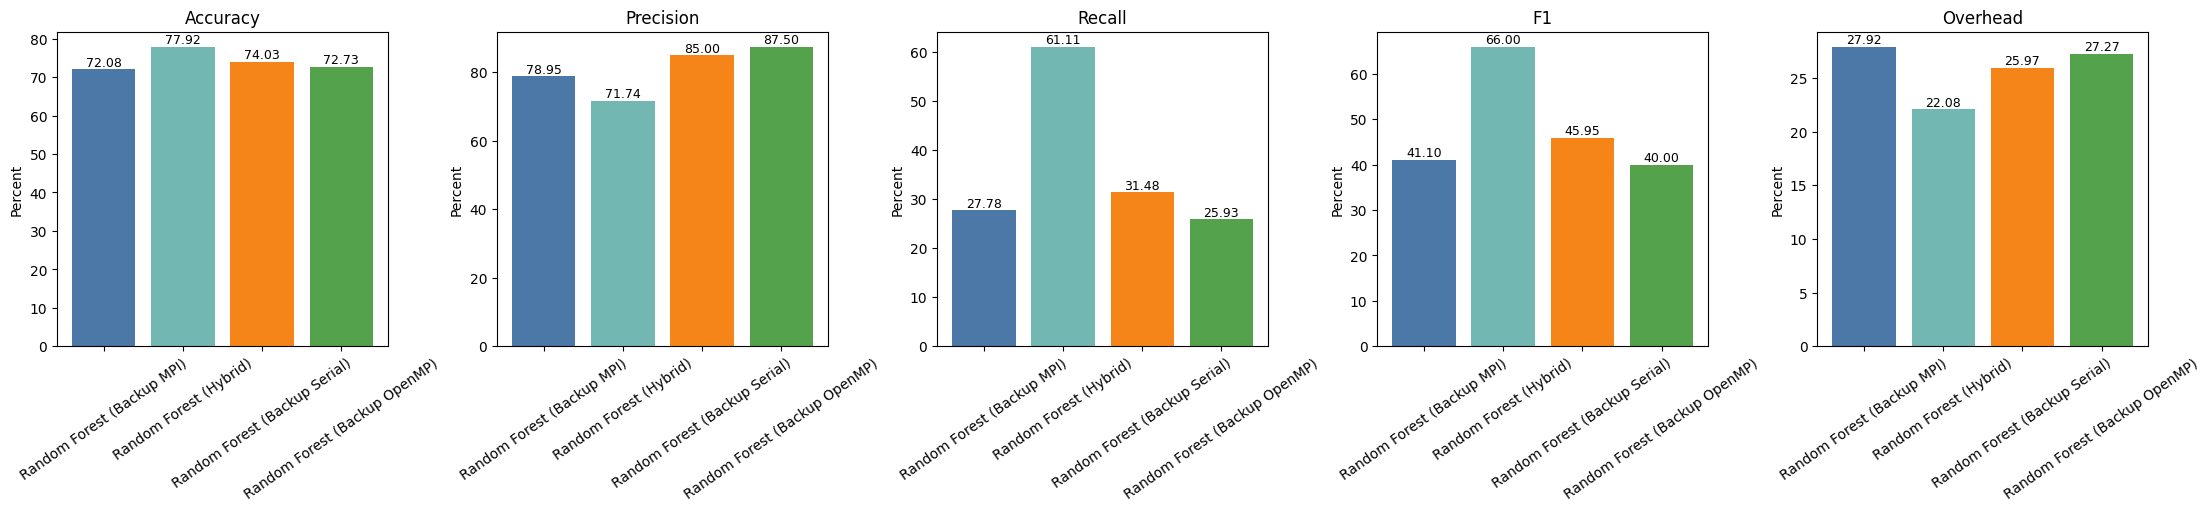

In [24]:
metric_columns = ["accuracy", "precision", "recall", "f1", "overhead"]
fig, axes = plt.subplots(1, len(metric_columns), figsize=(22, 5), constrained_layout=True)

for ax, metric in zip(axes, metric_columns):
    ax.bar(baseline_df["model_name"], baseline_df[metric], color=["#4C78A8", "#72B7B2", "#F58518", "#54A24B"])
    ax.set_title(metric.replace("_", " ").title())
    ax.set_ylabel("Percent")
    ax.tick_params(axis="x", rotation=35)
    for idx, value in enumerate(baseline_df[metric]):
        ax.text(idx, value, f"{value:.2f}", ha="center", va="bottom", fontsize=9)

plt.show()


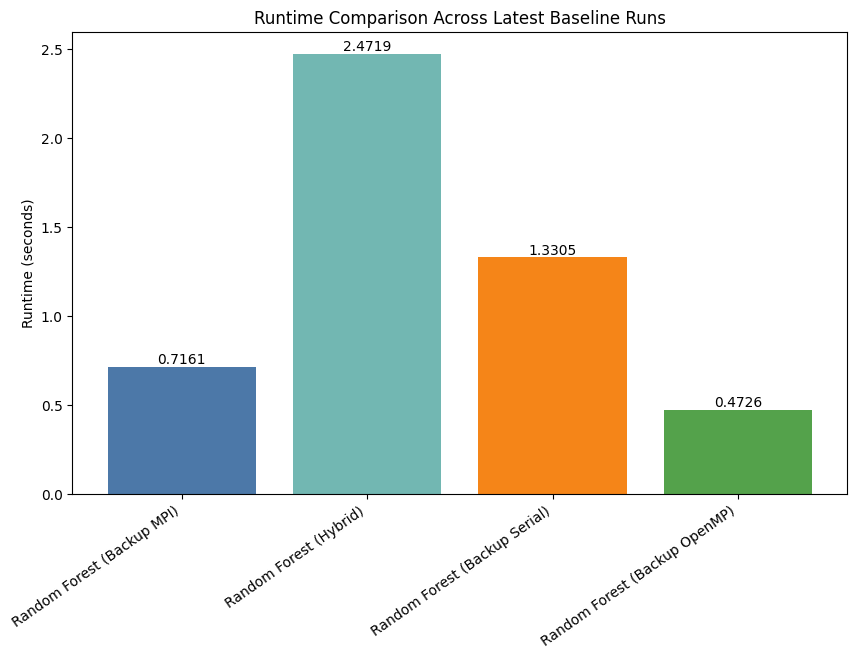

In [25]:
plt.figure(figsize=(10, 6))
plt.bar(baseline_df["model_name"], baseline_df["runtime_sec"], color=["#4C78A8", "#72B7B2", "#F58518", "#54A24B"])
plt.title("Runtime Comparison Across Latest Baseline Runs")
plt.ylabel("Runtime (seconds)")
plt.xticks(rotation=35, ha="right")
for idx, value in enumerate(baseline_df["runtime_sec"]):
    plt.text(idx, value, f"{value:.4f}", ha="center", va="bottom")
plt.show()


## Compare & Contrast: Serial vs OpenMP vs MPI vs Hybrid

- **Backup Serial:** Clean single-process baseline for the older Random Forest implementation.
- **Backup OpenMP:** Faster local threaded baseline, but not automatically better in validation quality.
- **Backup MPI:** Process-level baseline for the older implementation.
- **Hybrid MPI + OpenMP:** Strongest current reference because it combines the cleaner validation workflow with the newer histogram/binning design.


## Best Hybrid Configuration Only

This section focuses only on the strongest current Hybrid family:
- `trees=300`
- `max_depth=12`
- `min_samples_split=10`
- `max_features=2`
- split seeds `7, 21, 42, 84, 123`


In [26]:
best_hybrid = runs_df[
    (runs_df["model_name"] == "Random Forest (Hybrid)") &
    (runs_df["n_trees"] == 300) &
    (runs_df["max_depth"] == 12) &
    (runs_df["min_samples_split"] == 10) &
    (runs_df["max_features"] == 2)
].copy().sort_values("split_seed")

best_hybrid[[
    "split_seed", "accuracy", "precision", "recall", "f1", "runtime_sec", "run_name"
]]


,split_seed,accuracy,precision,recall,f1,runtime_sec,run_name
1,7,79.2208,82.3529,51.8519,63.6364,0.066813,run_20260430_204408_613_r2_seed7_t300_d12_ms10...
2,21,74.6753,68.2927,51.8519,58.9474,0.054147,run_20260430_204408_825_r2_seed21_t300_d12_ms1...
3,42,81.8182,77.0833,68.5185,72.5490,0.059396,run_20260430_204409_046_r2_seed42_t300_d12_ms1...
4,84,81.1688,72.7273,74.0741,73.3945,0.058068,run_20260430_204409_264_r2_seed84_t300_d12_ms1...
5,123,77.9221,71.7391,61.1111,66.0000,2.471890,run_20260430_204411_895_r2_seed123_t300_d12_ms...


In [27]:
best_hybrid_summary = pd.DataFrame([{
    "run_count": len(best_hybrid),
    "accuracy_mean": best_hybrid["accuracy"].mean(),
    "accuracy_std": best_hybrid["accuracy"].std(),
    "precision_mean": best_hybrid["precision"].mean(),
    "recall_mean": best_hybrid["recall"].mean(),
    "f1_mean": best_hybrid["f1"].mean(),
    "f1_std": best_hybrid["f1"].std(),
    "runtime_mean": best_hybrid["runtime_sec"].mean(),
}])
best_hybrid_summary


,run_count,accuracy_mean,accuracy_std,precision_mean,recall_mean,f1_mean,f1_std,runtime_mean
0,5,78.96104,2.852718,74.43906,61.4815,66.90546,6.099068,0.542063


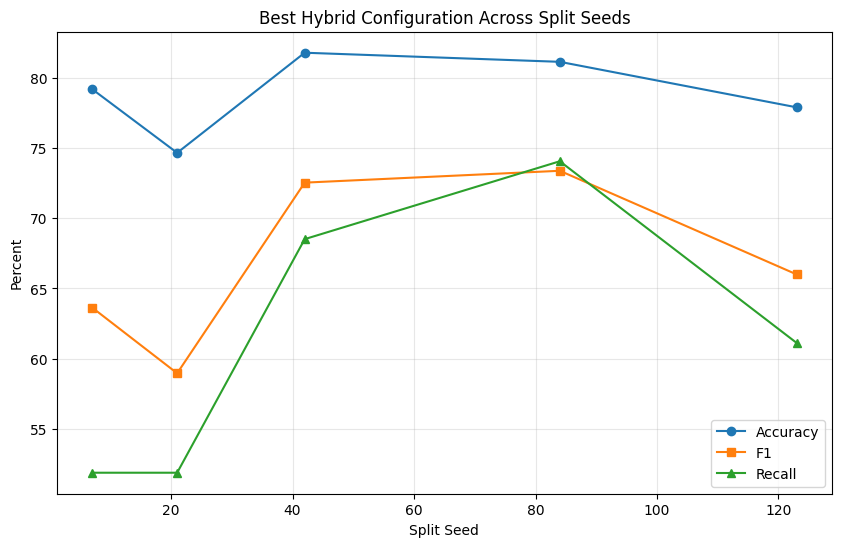

In [28]:
plt.figure(figsize=(10, 6))
plt.plot(best_hybrid["split_seed"], best_hybrid["accuracy"], marker="o", label="Accuracy")
plt.plot(best_hybrid["split_seed"], best_hybrid["f1"], marker="s", label="F1")
plt.plot(best_hybrid["split_seed"], best_hybrid["recall"], marker="^", label="Recall")
plt.title("Best Hybrid Configuration Across Split Seeds")
plt.xlabel("Split Seed")
plt.ylabel("Percent")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


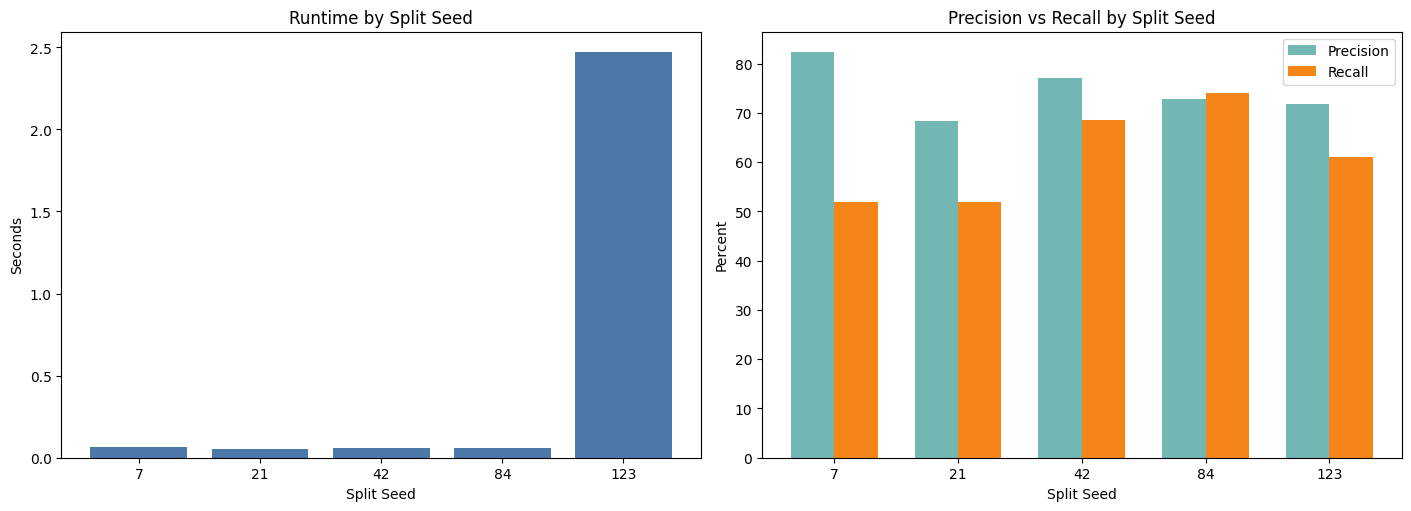

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
axes[0].bar(best_hybrid["split_seed"].astype(str), best_hybrid["runtime_sec"], color="#4C78A8")
axes[0].set_title("Runtime by Split Seed")
axes[0].set_xlabel("Split Seed")
axes[0].set_ylabel("Seconds")

x = np.arange(len(best_hybrid))
width = 0.35
axes[1].bar(x - width/2, best_hybrid["precision"], width, label="Precision", color="#72B7B2")
axes[1].bar(x + width/2, best_hybrid["recall"], width, label="Recall", color="#F58518")
axes[1].set_title("Precision vs Recall by Split Seed")
axes[1].set_xticks(x)
axes[1].set_xticklabels(best_hybrid["split_seed"].astype(str))
axes[1].set_xlabel("Split Seed")
axes[1].set_ylabel("Percent")
axes[1].legend()
plt.show()


## Compare & Contrast: Best Hybrid Only

- This focused view removes the clutter from older experiments and keeps attention on the strongest current Hybrid family.
- The main quantity to watch is **mean F1**, but the seed-to-seed spread still matters.
- A good default configuration is one that keeps solid F1 while avoiding large variance or unexpectedly slow runtime on certain seeds.


## Conclusions

- **Best current view:** Focus on the curated baseline comparison and the best Hybrid configuration across seeds `7, 21, 42, 84, 123`.
- **Best Hybrid family:** `trees=300`, `max_depth=12`, `min_samples_split=10`, `max_features=2`.
- **Most useful metrics:** F1 and recall tell the clearest story here, while runtime shows implementation cost.
- **Main takeaway:** The current Hybrid pipeline is the strongest overall reference, but the gain comes from the cleaner evaluation workflow and improved implementation, not from parallelism alone.
